In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, zipfile, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

Mounted at /content/drive
TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
PROJECT   = "/content/drive/MyDrive/Skin_Disease_Project"
ZIP_FILE  = f"{PROJECT}/dataset/archive.zip"
DATA_DIR  = "/content/data"

if not os.path.exists(f"{DATA_DIR}/Split_smol"):
    with zipfile.ZipFile(ZIP_FILE) as z:
        z.extractall(DATA_DIR)
    print("✅ Extracted")
else:
    print("✅ Already extracted")

train_path = f"{DATA_DIR}/Split_smol/train"
val_path   = f"{DATA_DIR}/Split_smol/val"
print(os.listdir(train_path))

✅ Extracted
['Benign keratosis', 'Vascular lesion', 'Tinea Ringworm Candidiasis', 'Melanocytic nevus', 'Squamous cell carcinoma', 'Atopic Dermatitis', 'Dermatofibroma', 'Actinic keratosis', 'Melanoma']


Found 697 files belonging to 9 classes.
Found 181 files belonging to 9 classes.
['Actinic keratosis', 'Atopic Dermatitis', 'Benign keratosis', 'Dermatofibroma', 'Melanocytic nevus', 'Melanoma', 'Squamous cell carcinoma', 'Tinea Ringworm Candidiasis', 'Vascular lesion']


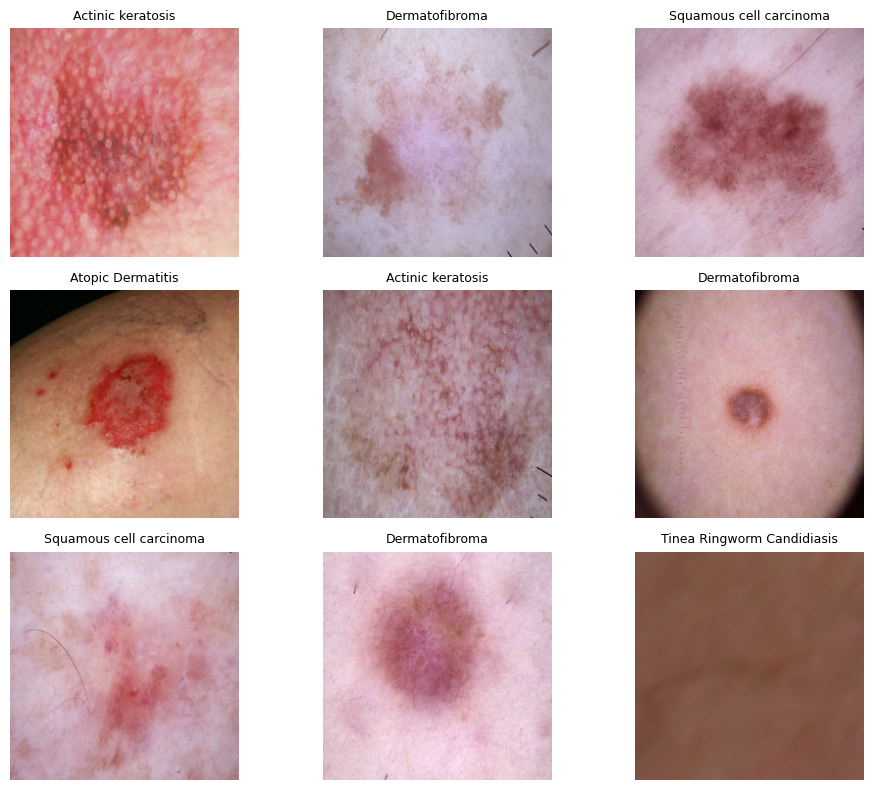

In [6]:
IMG_SIZE, BATCH_SIZE, SEED = (224, 224), 32, 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

# Sample images
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis("off")
plt.tight_layout(); plt.show()

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False

# NOTE: model ke andar Rescaling hai, isliye app me dobara /255 NAHI karna
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax"),
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True)

history1 = model.fit(train_ds, validation_data=val_ds,
                     epochs=15, callbacks=[early_stop])

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 327ms/step - accuracy: 0.2095 - loss: 2.3753 - val_accuracy: 0.4144 - val_loss: 1.6474
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.4103 - loss: 1.6662 - val_accuracy: 0.6022 - val_loss: 1.2716
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.5237 - loss: 1.3749 - val_accuracy: 0.6685 - val_loss: 1.1035
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.5811 - loss: 1.1918 - val_accuracy: 0.6519 - val_loss: 1.0842
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - accuracy: 0.6126 - loss: 1.1399 - val_accuracy: 0.7238 - val_loss: 0.9776
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 239ms/step - accuracy: 0.6456 - loss: 1.0116 - val_accuracy: 0.6906 - val_loss: 0.9596
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 425ms/step - accuracy: 0.6284 - loss: 0.9840 - val_accuracy: 0.6961 - val_loss: 0.9344
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 464ms/step - accuracy: 0.6815 - loss: 0.9373 - val_accuracy:

In [9]:
base_model.trainable = True
for layer in base_model.layers[:-30]:      # sirf last 30 layers train honge
    layer.trainable = False
for layer in base_model.layers:            # BatchNorm freeze rakho (stable training)
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop_ft = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=6, restore_best_weights=True)

history2 = model.fit(train_ds, validation_data=val_ds,
                     epochs=25, callbacks=[early_stop_ft])

Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.7418 - loss: 0.7337 - val_accuracy: 0.7072 - val_loss: 0.8595
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.7504 - loss: 0.6725 - val_accuracy: 0.7569 - val_loss: 0.8139
Epoch 3/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step - accuracy: 0.7561 - loss: 0.6624 - val_accuracy: 0.7459 - val_loss: 0.8486
Epoch 4/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.7661 - loss: 0.6229 - val_accuracy: 0.7293 - val_loss: 0.8464
Epoch 5/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.7848 - loss: 0.5883 - val_accuracy: 0.7348 - val_loss: 0.8252
Epoch 6/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 282ms/step - accuracy: 0.7991 - loss: 0.5788 - val_accuracy: 0.7459 - val_loss: 0.8099
Epoch 7/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 183ms/step - accuracy: 0.7690 - loss: 0.6158 - val_accuracy: 0.7293 - val_loss: 0.8073
Epoch 8/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 265ms/step - accuracy: 0.7934 - loss: 0.6063 - val_accuracy: 0

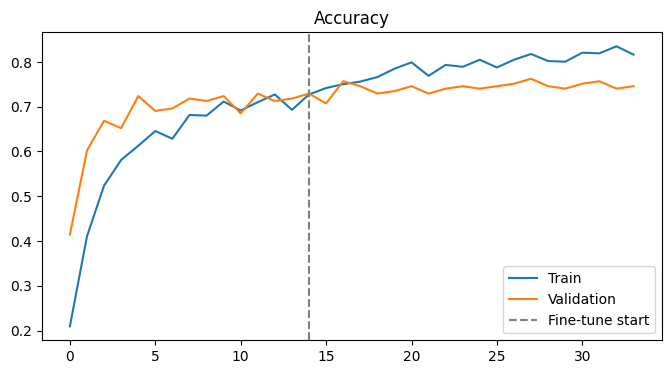

Validation Accuracy: 76.24%
                            precision    recall  f1-score   support

         Actinic keratosis       0.90      0.45      0.60        20
         Atopic Dermatitis       0.95      1.00      0.98        21
          Benign keratosis       0.86      0.90      0.88        20
            Dermatofibroma       0.64      0.70      0.67        20
         Melanocytic nevus       1.00      0.60      0.75        20
                  Melanoma       0.44      0.55      0.49        20
   Squamous cell carcinoma       0.50      0.75      0.60        20
Tinea Ringworm Candidiasis       1.00      0.95      0.97        20
           Vascular lesion       0.95      0.95      0.95        20

                  accuracy                           0.76       181
                 macro avg       0.80      0.76      0.76       181
              weighted avg       0.81      0.76      0.77       181



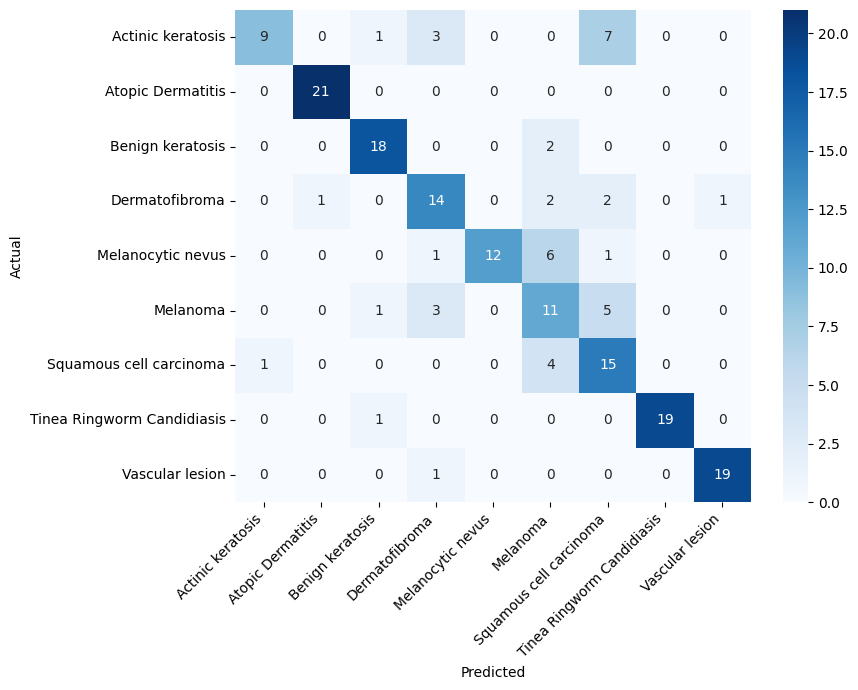

In [10]:
acc  = history1.history["accuracy"] + history2.history["accuracy"]
vacc = history1.history["val_accuracy"] + history2.history["val_accuracy"]
plt.figure(figsize=(8, 4))
plt.plot(acc, label="Train"); plt.plot(vacc, label="Validation")
plt.axvline(len(history1.history["accuracy"]) - 1, color="gray", ls="--", label="Fine-tune start")
plt.title("Accuracy"); plt.legend(); plt.show()

val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

y_true, y_pred = [], []
for images, labels in val_ds:
    p = model.predict(images, verbose=0)
    y_true.extend(labels.numpy()); y_pred.extend(np.argmax(p, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

In [11]:
MODEL_PATH = f"{PROJECT}/skin_disease_mobilenetv2.keras"
CLASS_PATH = f"{PROJECT}/class_names.json"

model.save(MODEL_PATH)
with open(CLASS_PATH, "w") as f:
    json.dump(class_names, f)
print("✅ Saved:", MODEL_PATH)

✅ Saved: /content/drive/MyDrive/Skin_Disease_Project/skin_disease_mobilenetv2.keras


Saving 123.jpg to 123.jpg


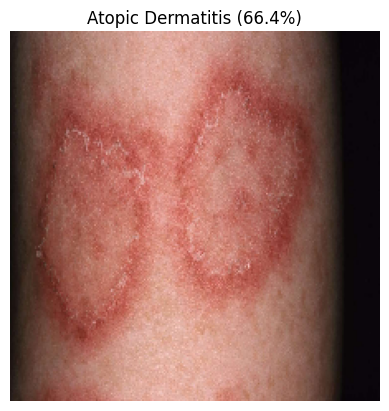

In [12]:
from google.colab import files
uploaded = files.upload()
name = list(uploaded.keys())[0]

img = tf.keras.utils.load_img(name, target_size=(224, 224))
arr = tf.expand_dims(tf.keras.utils.img_to_array(img), 0)
pred = model.predict(arr, verbose=0)[0]
i = int(np.argmax(pred))

plt.imshow(img); plt.axis("off")
plt.title(f"{class_names[i]} ({pred[i]*100:.1f}%)"); plt.show()

In [13]:
APP_CODE = r'''
import streamlit as st
import tensorflow as tf
import numpy as np
import json
from PIL import Image

st.set_page_config(page_title="SkinCare AI", page_icon="🩺", layout="wide")

MODEL_PATH = "/content/drive/MyDrive/Skin_Disease_Project/skin_disease_mobilenetv2.keras"
CLASS_PATH = "/content/drive/MyDrive/Skin_Disease_Project/class_names.json"

INFO = {
    "Actinic keratosis": ("Rough, scaly patches from long sun exposure. Can become cancerous, so needs a doctor's check.", True),
    "Atopic Dermatitis": ("Eczema: dry, itchy, inflamed skin. Usually managed with moisturisers and doctor-advised creams.", False),
    "Benign keratosis": ("Non-cancerous waxy or scaly growths, common with age. Usually harmless.", False),
    "Dermatofibroma": ("Small, firm, harmless skin nodule, often on the legs.", False),
    "Melanocytic nevus": ("Common mole. Watch for changes in size, shape or colour.", False),
    "Melanoma": ("A serious type of skin cancer. Early detection matters - see a dermatologist promptly.", True),
    "Squamous cell carcinoma": ("A common skin cancer that is treatable when found early. See a dermatologist.", True),
    "Tinea Ringworm Candidiasis": ("Fungal skin infections, often ring-shaped and itchy. Usually treated with antifungals.", False),
    "Vascular lesion": ("Blood-vessel related marks such as angiomas. Often harmless.", False),
}

st.markdown("""
<style>
.stApp {background: radial-gradient(circle at 10% 10%, #172554 0%, transparent 30%),
        radial-gradient(circle at 90% 90%, #164e63 0%, transparent 30%), #020617; color:#f8fafc;}
.hero {text-align:center; padding: 10px 0 25px 0;}
.hero h1 {font-size:48px; font-weight:800; margin:0;}
.hero p {color:#94a3b8; font-size:18px;}
.card {background: rgba(15,23,42,.8); border:1px solid rgba(148,163,184,.2);
       border-radius:22px; padding:24px; margin-bottom:16px;}
.disease {font-size:32px; font-weight:800; color:#38bdf8;}
.conf {font-size:20px; color:#a7f3d0; font-weight:700;}
.warn {background:rgba(245,158,11,.1); border:1px solid rgba(245,158,11,.35);
       border-radius:14px; padding:14px; color:#fbbf24;}
.danger {background:rgba(239,68,68,.1); border:1px solid rgba(239,68,68,.4);
       border-radius:14px; padding:14px; color:#fca5a5;}
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_all():
    m = tf.keras.models.load_model(MODEL_PATH)
    with open(CLASS_PATH) as f:
        c = json.load(f)
    return m, c

model, class_names = load_all()

st.markdown('<div class="hero"><h1>🩺 SkinCare AI</h1><p>AI-powered skin disease screening (educational project)</p></div>',
            unsafe_allow_html=True)

left, right = st.columns(2, gap="large")
with left:
    st.markdown("### 📸 Upload Skin Image")
    file = st.file_uploader("JPG / JPEG / PNG", type=["jpg", "jpeg", "png"])
    st.caption("Tip: clear, well-lit, close-up photo of the affected area works best.")
with right:
    if file:
        image = Image.open(file).convert("RGB")
        st.image(image, caption="Uploaded image")
    else:
        st.info("Waiting for image...")

if file and st.button("🔍 Analyze Skin", use_container_width=True):
    with st.spinner("Analyzing..."):
        x = np.array(image.resize((224, 224)), dtype=np.float32)   # /255 model ke andar hota hai
        x = np.expand_dims(x, 0)
        probs = model.predict(x, verbose=0)[0]
        top = np.argsort(probs)[::-1][:3]

    best = class_names[top[0]]
    conf = probs[top[0]] * 100
    desc, serious = INFO.get(best, ("", False))

    st.markdown(f"""<div class="card">
        <div style="color:#94a3b8">AI SCREENING RESULT</div>
        <div class="disease">🔎 {best}</div>
        <div class="conf">Confidence: {conf:.1f}%</div>
        <p style="color:#cbd5e1; margin-top:10px">{desc}</p></div>""", unsafe_allow_html=True)

    if conf < 50:
        st.markdown('<div class="warn">⚠️ Model is not very sure about this image. Treat the result with extra caution.</div>',
                    unsafe_allow_html=True)
    if serious:
        st.markdown('<div class="danger">🚨 This category can be serious. Please see a dermatologist for a proper check-up.</div>',
                    unsafe_allow_html=True)

    st.subheader("📊 Top 3 predictions")
    for i in top:
        st.write(f"**{class_names[i]}** - {probs[i]*100:.1f}%")
        st.progress(float(probs[i]))

st.markdown("""<div class="warn" style="margin-top:20px">
This is an educational AI project, <b>not a medical diagnosis</b>. Predictions can be wrong.
Always consult a qualified doctor.</div>""", unsafe_allow_html=True)
'''

with open("/content/drive/MyDrive/Skin_Disease_Project/app.py", "w") as f:
    f.write(APP_CODE)
print("✅ app.py saved")

✅ app.py saved


In [15]:
!pip install -q streamlit
!npm install -g localtunnel > /dev/null 2>&1
!pkill -f streamlit
!nohup streamlit run /content/drive/MyDrive/Skin_Disease_Project/app.py --server.port 8501 --server.headless true > /content/streamlit.log 2>&1 &
!sleep 8
print("👇 Tunnel PASSWORD (ye IP copy karo):")
!curl -s https://ipv4.icanhazip.com

👇 Tunnel PASSWORD (ye IP copy karo):
34.13.192.64


In [ ]:
!lt --port 8501

your url is: https://big-areas-help.loca.lt
